In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors,rdFingerprintGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import PandasTools

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

sns.set_theme(style="white")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "axes.edgecolor": "black",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

1、Load the training set and testing set

In [2]:
train_data=pd.read_csv("data/train.csv")
test_data=pd.read_csv("data/test.csv")

In [3]:
train_data.head()

,SMILES,shift_value
0,O=S(=O)(N[C@@H]1C[C@H]1C1CCC(F)CC1)C1CCCO1,-117.37
1,OC1NCN(-C2CCC(C(F)(F)F)CC2)N1,-61.70
2,CC1(C)CN(C(=O)CC2CCCCC2F)CCS1(=O)=O,-117.64
3,CNC(=O)N1CCC(CC(F)(F)F)CC1,-62.83
4,CN(C(=O)CC1CCC(F)CC1)C1CCCC(C#N)C1,-116.45


In [4]:
test_data.head()

,SMILES,shift_value
0,CC1C(C(F)(F)F)N[NH]C1CO,-61.30
1,C=CF,-113.00
2,CCC1NNSC1C(=O)N1CCCC(C(F)(F)F)C1,-71.43
3,CC(C)(OC1CCC(F)CC1)C(=O)N1CCCC1,-121.58
4,CCOC(=O)C1(C(=O)OCC)CC2CC(-C3CCC(Cl)CC3)C(C(F)...,-57.02


In [5]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2320 entries, 0 to 2319
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SMILES       2320 non-null   object 
 1   shift_value  2320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 36.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SMILES       581 non-null    object 
 1   shift_value  581 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.2+ KB


In [6]:
# Check if there is None in our dataset 
missing_values = train_data.isnull().sum()
print(missing_values)
missing_values = test_data.isnull().sum()
print(missing_values)

SMILES         0
shift_value    0
dtype: int64
SMILES         0
shift_value    0
dtype: int64


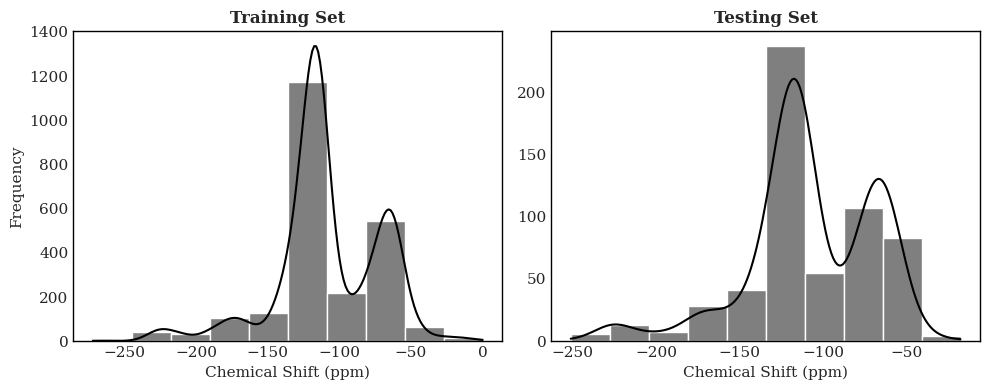

In [7]:
# Visualize the Chemical shift distribution
fig, axs = plt.subplots(1, 2, figsize=(10, 4))  


sns.histplot(train_data["shift_value"], bins=10, kde=True, color='black', edgecolor=None, ax=axs[0])
axs[0].set_title('Training Set', weight="bold")
axs[0].set_xlabel('Chemical Shift (ppm)')
axs[0].set_ylabel('Frequency')


sns.histplot(test_data["shift_value"], bins=10, kde=True, color='black', edgecolor=None, ax=axs[1])
axs[1].set_title('Testing Set', weight="bold")
axs[1].set_xlabel('Chemical Shift (ppm)')
axs[1].set_ylabel('')


plt.tight_layout()
plt.show()

2、Data Preprocessing

In [8]:
# Add molecule objects column
PandasTools.AddMoleculeColumnToFrame(train_data, smilesCol='SMILES')
PandasTools.AddMoleculeColumnToFrame(test_data, smilesCol='SMILES')

# Initialize storage columns
train_data['MorganFP'] = None  # For Morgan fingerprints (count vector)
test_data['MorganFP'] = None  
train_data['MACCSKeys'] = None  # For MACCS keys
test_data['MACCSKeys'] = None  
train_data['RDKitDescriptors'] = None  # For descriptor dictionaries
test_data['RDKitDescriptors'] = None  

# Initialize the Morgan fingerprint generator for count vector

for idx, row in train_data.iterrows():
    mol = row['ROMol']
    if mol is None:
        continue
    
    # Generate Morgan fingerprint as count vector 
    train_data.at[idx, 'MorganFP'] = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    
    # Generate MACCS keys
    train_data.at[idx, 'MACCSKeys'] = MACCSkeys.GenMACCSKeys(mol)
    
    # Calculate RDKit descriptors
    train_data.at[idx, 'RDKitDescriptors'] = Descriptors.CalcMolDescriptors(mol)

# Calculate molecular features for test data
for idx, row in test_data.iterrows():
    mol = row['ROMol']
    if mol is None:
        continue
    
    # Generate Morgan fingerprint as count vector
    test_data.at[idx, 'MorganFP'] = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    
    # Generate MACCS keys
    test_data.at[idx, 'MACCSKeys'] = MACCSkeys.GenMACCSKeys(mol)
    
    # Calculate RDKit descriptors
    test_data.at[idx, 'RDKitDescriptors'] = Descriptors.CalcMolDescriptors(mol)


[08:45:03] DEPRECATION WARNING: please use MorganGenerator


[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerator
[08:45:04] DEPRECATION WARNING: please use MorganGenerat

In [9]:
# Extract the length of three descriptors
# MorganFP
print("The length of MorganFP is:", len(train_data['MorganFP'].iloc[0]))
# MACCSKeys
print("The length of MACCSKeys is:", len(train_data['MACCSKeys'].iloc[0]))
# RDKit Descriptor
descriptor_names = [desc[0] for desc in Descriptors.descList]
print("The length of RDKit descriptors is:",len(descriptor_names))
print(descriptor_names)
print(len(descriptor_names))

The length of MorganFP is: 2048
The length of MACCSKeys is: 167
The length of RDKit descriptors is: 210
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3',

In [10]:
train_data.head()

,SMILES,shift_value,ROMol,MorganFP,MACCSKeys,RDKitDescriptors
0,O=S(=O)(N[C@@H]1C[C@H]1C1CCC(F)CC1)C1CCCO1,-117.37,<rdkit.Chem.rdchem.Mol object at 0x7ffa0bafdbd0>,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 13.085410040980477, 'Max..."
1,OC1NCN(-C2CCC(C(F)(F)F)CC2)N1,-61.70,<rdkit.Chem.rdchem.Mol object at 0x7ffa0bafdd90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 12.426080666834634, 'Max..."
2,CC1(C)CN(C(=O)CC2CCCCC2F)CCS1(=O)=O,-117.64,<rdkit.Chem.rdchem.Mol object at 0x7ffa0bafde00>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 13.784091487675317, 'Max..."
3,CNC(=O)N1CCC(CC(F)(F)F)CC1,-62.83,<rdkit.Chem.rdchem.Mol object at 0x7ffa0bafde70>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 12.069154226505418, 'Max..."
4,CN(C(=O)CC1CCC(F)CC1)C1CCCC(C#N)C1,-116.45,<rdkit.Chem.rdchem.Mol object at 0x7ffa0bafdee0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 13.099821714693858, 'Max..."


In [11]:
test_data.head()

,SMILES,shift_value,ROMol,MorganFP,MACCSKeys,RDKitDescriptors
0,CC1C(C(F)(F)F)N[NH]C1CO,-61.30,<rdkit.Chem.rdchem.Mol object at 0x7ffa0bafd9a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 12.136695956160242, 'Max..."
1,C=CF,-113.00,<rdkit.Chem.rdchem.Mol object at 0x7ffa0ad8dfc0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 10.055555555555555, 'Max..."
2,CCC1NNSC1C(=O)N1CCCC(C(F)(F)F)C1,-71.43,<rdkit.Chem.rdchem.Mol object at 0x7ffa0ad8e030>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 12.730255023305618, 'Max..."
3,CC(C)(OC1CCC(F)CC1)C(=O)N1CCCC1,-121.58,<rdkit.Chem.rdchem.Mol object at 0x7ffa0ad8e0a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 13.063348982767273, 'Max..."
4,CCOC(=O)C1(C(=O)OCC)CC2CC(-C3CCC(Cl)CC3)C(C(F)...,-57.02,<rdkit.Chem.rdchem.Mol object at 0x7ffa0ad8e110>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'MaxAbsEStateIndex': 14.022127208431922, 'Max..."


In [12]:
X_train_morgan = np.stack(train_data['MorganFP'].apply(lambda x: np.array(x, dtype=np.float32)))
X_train_maccs = np.stack(train_data['MACCSKeys'].apply(lambda x: np.array(x, dtype=np.float32)))
X_test_morgan = np.stack(test_data['MorganFP'].apply(lambda x: np.array(x, dtype=np.float32)))
X_test_maccs = np.stack(test_data['MACCSKeys'].apply(lambda x: np.array(x, dtype=np.float32)))
all_descriptors = set()
for desc_dict in train_data['RDKitDescriptors']:
    all_descriptors.update(desc_dict.keys())
all_descriptors = sorted(list(all_descriptors))

def convert_rdkit_desc(desc_dict):
    return [desc_dict.get(key, np.nan) for key in all_descriptors]

X_train_rdkit = np.array([convert_rdkit_desc(d) for d in train_data['RDKitDescriptors']])
X_test_rdkit = np.array([convert_rdkit_desc(d) for d in test_data['RDKitDescriptors']])

# Fill the NaN with the mean value
imputer = SimpleImputer(strategy='mean')
X_train_rdkit = imputer.fit_transform(X_train_rdkit)
X_test_rdkit = imputer.transform(X_test_rdkit)

y_train = train_data['shift_value'].values
y_test = test_data['shift_value'].values

scaler = StandardScaler()
X_scaled_train_rdkit = scaler.fit_transform(X_train_rdkit)
X_scaled_test_rdkit = scaler.transform(X_test_rdkit)

3、Multiple Model Training

In [13]:
# The models we want to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector": SVR(),
    "KNN": KNeighborsRegressor()
}

# The features to input
features = {
    "MorganFP": X_train_morgan,
    "MACCSKeys": X_train_maccs,
    "RDKitDescriptors": X_train_rdkit,
    "ScaledRDKitDescriptors": X_scaled_train_rdkit
}

results = []

# Run all models and features
for model_name, model in models.items():
    for feat_name, X in features.items():
        # Train model
        model.fit(X, y_train)
        y_pred = model.predict(X)
        r2 = r2_score(y_train, y_pred)
        rmse = np.sqrt(mean_squared_error(y_train, y_pred))
        results.append({
            "Model": model_name,
            "Feature": feat_name,
            "R2": r2,
            "RMSE": rmse
        })

results_df = pd.DataFrame(results)

/home/yyt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.42229e-26): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


/tmp/ipykernel_2886509/2803070484.py:6: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=results_df, x="R2", y="Model", hue="Feature", orient="h", ax=axs[0], palette=palette)
/tmp/ipykernel_2886509/2803070484.py:21: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=results_df, x="RMSE", y="Model", hue="Feature", orient="h", ax=axs[1], palette=palette)


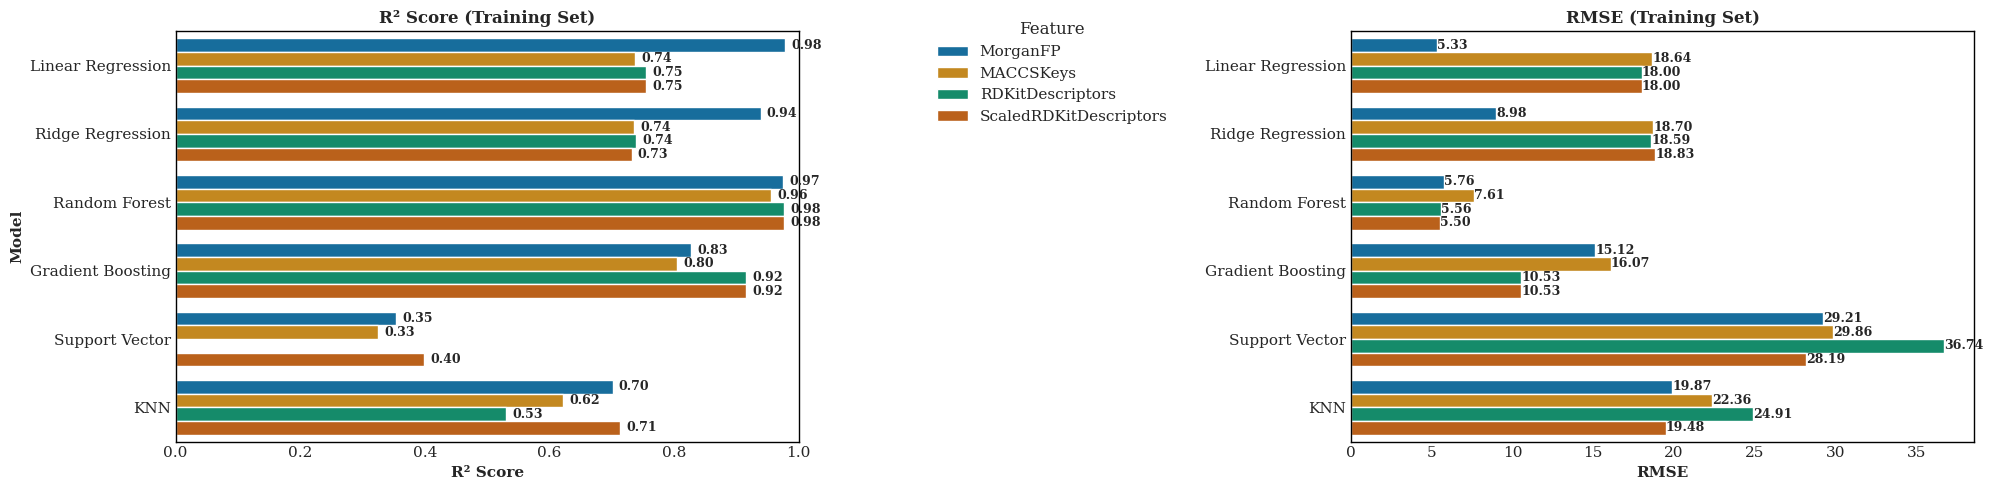

In [14]:
palette = sns.color_palette("colorblind")  # 或 "deep", "muted"

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# R²
sns.barplot(data=results_df, x="R2", y="Model", hue="Feature", orient="h", ax=axs[0], palette=palette)
axs[0].set_title("R² Score (Training Set)",weight="bold")
axs[0].set_xlabel("R² Score",weight="bold")
axs[0].set_xlim(0, 1)
axs[0].set_ylabel("Model",weight="bold")
# axs[0].legend(loc='best', frameon=False)
axs[0].legend(title="Feature", loc='center left', bbox_to_anchor=(1.2, 0.9), frameon=False)

for p in axs[0].patches:
    width = p.get_width()
    if width > 0.01:
        axs[0].text(width + 0.01, p.get_y() + p.get_height()/2,
                    f'{width:.2f}', ha='left', va='center', fontsize=9,weight="bold")

# RMSE
sns.barplot(data=results_df, x="RMSE", y="Model", hue="Feature", orient="h", ax=axs[1], palette=palette)
axs[1].set_title("RMSE (Training Set)",weight="bold")
axs[1].set_xlabel("RMSE",weight="bold")
axs[1].set_ylabel("")
# axs[1].legend(loc='best', frameon=False)
axs[1].get_legend().remove()

for p in axs[1].patches:
    width = p.get_width()
    if width > 0.01:
        axs[1].text(width + 0.01, p.get_y() + p.get_height()/2,
                    f'{width:.2f}', ha='left', va='center', fontsize=9,weight="bold")

plt.tight_layout()
plt.show()

4、Further Adjustment with RandomForest

In [15]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5,10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Define the evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    return {
        "Train R2": r2_score(y_train, y_pred_train),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test R2": r2_score(y_test, y_pred_test),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test))
    }

features = {
    "Morgan": X_train_morgan,
    "MACCS": X_train_maccs,
    "RDKit": X_train_rdkit,
    "ScaledRDKitDescriptors": X_scaled_train_rdkit
}

results = []
best_models = {}

for feat_name, X_train in features.items():
    print(f"\n=== Processing: {feat_name} ===")
    
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    best_models[feat_name] = best_model
    
    if feat_name == "ScaledRDKitDescriptors":
        X_test = X_scaled_test_rdkit 
    else:
        X_test = eval(f"X_test_{feat_name.lower()}")  
    
    metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test)
    results.append({
        "Feature": feat_name,
        "Best Params": grid_search.best_params_,
        **metrics
    })

results_df = pd.DataFrame(results)


=== Processing: Morgan ===



=== Processing: MACCS ===

=== Processing: RDKit ===

=== Processing: ScaledRDKitDescriptors ===


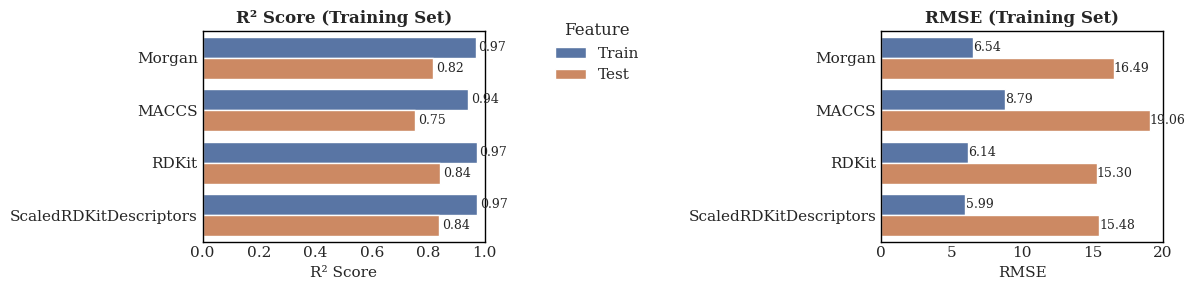

In [16]:
r2_df = results_df.melt(
    id_vars="Feature", 
    value_vars=["Train R2", "Test R2"],
    var_name="Dataset", 
    value_name="R2"
)
r2_df["Dataset"] = r2_df["Dataset"].str.replace(" R2", "") 

rmse_df = results_df.melt(
    id_vars="Feature", 
    value_vars=["Train RMSE", "Test RMSE"],
    var_name="Dataset", 
    value_name="RMSE"
)
rmse_df["Dataset"] = rmse_df["Dataset"].str.replace(" RMSE", "")

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

# R² 
sns.barplot(
    data=r2_df,
    x="R2", 
    y="Feature", 
    hue="Dataset",
    palette={"Train": "#4C72B0", "Test": "#DD8452"},  
    dodge=True,
    ax=axs[0]
)
axs[0].set_title("R² Score (Training Set)", weight="bold")
axs[0].set_xlabel("R² Score")
axs[0].set_ylabel("")
axs[0].set_xlim(0, 1)
axs[0].legend(title="Feature", loc='center left', bbox_to_anchor=(1.2, 0.9), frameon=False)
for p in axs[0].patches:
    width = p.get_width()
    if width > 0.01:
        axs[0].text(width + 0.01, p.get_y() + p.get_height()/2,
                    f'{width:.2f}', ha='left', va='center', fontsize=9)

# RMSE 
sns.barplot(
    data=rmse_df,
    x="RMSE", 
    y="Feature", 
    hue="Dataset",
    palette={"Train": "#4C72B0", "Test": "#DD8452"},
    dodge=True,
    ax=axs[1]
)
axs[1].set_title("RMSE (Training Set)", weight="bold")
axs[1].set_xlabel("RMSE")
axs[1].set_ylabel("")
axs[1].get_legend().remove()

for p in axs[1].patches:
    width = p.get_width()
    if width > 0.01:
        axs[1].text(width + 0.01, p.get_y() + p.get_height()/2,
                    f'{width:.2f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

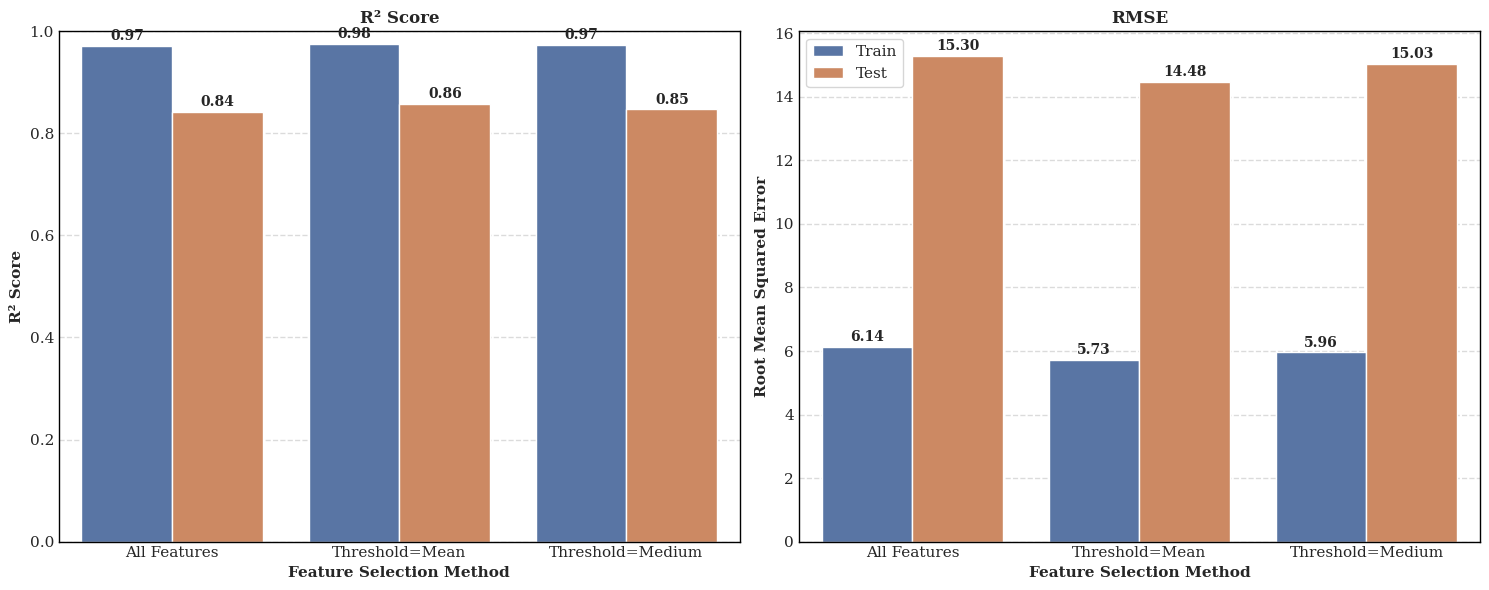

In [21]:
# Weather to perform feature selection or not
best_model = clone(best_models["RDKit"])
metrics_all = evaluate_model(best_model, X_train_rdkit, y_train, X_test_rdkit, y_test)


# Perform feature selection based on tree model
selector_mean = SelectFromModel(
    estimator=best_model,
    threshold="mean",  
    prefit=True         
)
X_train_selected_mean = selector_mean.transform(X_train_rdkit)
X_test_selected_mean = selector_mean.transform(X_test_rdkit)
best_model_mean = clone(best_models["RDKit"])
best_model_mean.fit(X_train_selected_mean, y_train)
metrics_mean= evaluate_model(best_model_mean, X_train_selected_mean, y_train, X_test_selected_mean, y_test)

selector_medium = SelectFromModel(
    estimator=best_model,
    threshold="median",  
    prefit=True         
)
X_train_selected_median = selector_medium.transform(X_train_rdkit)
X_test_selected_median = selector_medium.transform(X_test_rdkit)
best_model_median = clone(best_models["RDKit"])
best_model_median.fit(X_train_selected_median, y_train)
metrics_median= evaluate_model(best_model_median, X_train_selected_median, y_train, X_test_selected_median, y_test)

df_r2 = pd.DataFrame({
    "Feature Selection": ["All Features", "Threshold=Mean", "Threshold=Medium"],
    "Train R2": [metrics_all['Train R2'], metrics_mean['Train R2'], metrics_median['Train R2']],
    "Test R2": [metrics_all['Test R2'], metrics_mean['Test R2'], metrics_median['Test R2']]
}).melt(id_vars="Feature Selection", var_name="Dataset", value_name="R2")

df_rmse = pd.DataFrame({
    "Feature Selection": ["All Features", "Threshold=Mean", "Threshold=Medium"],
    "Train RMSE": [metrics_all['Train RMSE'], metrics_mean['Train RMSE'], metrics_median['Train RMSE']],
    "Test RMSE": [metrics_all['Test RMSE'], metrics_mean['Test RMSE'], metrics_median['Test RMSE']]
}).melt(id_vars="Feature Selection", var_name="Dataset", value_name="RMSE")

df_r2['Dataset'] = df_r2['Dataset'].str.replace(" R2", "")
df_rmse['Dataset'] = df_rmse['Dataset'].str.replace(" RMSE", "")

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=df_r2, x="Feature Selection", y="R2", hue="Dataset", ax=axs[0])
for container in axs[0].containers:
    axs[0].bar_label(container, fmt="%.2f", label_type="edge", padding=2,weight="bold")
axs[0].set_ylim(0, 1)
axs[0].set_title("R² Score",weight="bold")
axs[0].set_xlabel("Feature Selection Method",weight="bold")
axs[0].set_ylabel("R² Score",weight="bold")
axs[0].grid(axis='y', linestyle='--', alpha=0.7)
axs[0].get_legend().remove()

sns.barplot(data=df_rmse, x="Feature Selection", y="RMSE", hue="Dataset", ax=axs[1])
for container in axs[1].containers:
    axs[1].bar_label(container, fmt="%.2f", label_type="edge", padding=2,weight="bold")
axs[1].set_title("RMSE",weight="bold")
axs[1].set_xlabel("Feature Selection Method",weight="bold")
axs[1].set_ylabel("Root Mean Squared Error",weight="bold")
axs[1].grid(axis='y', linestyle='--', alpha=0.7)
axs[1].legend()

plt.tight_layout()
plt.show()

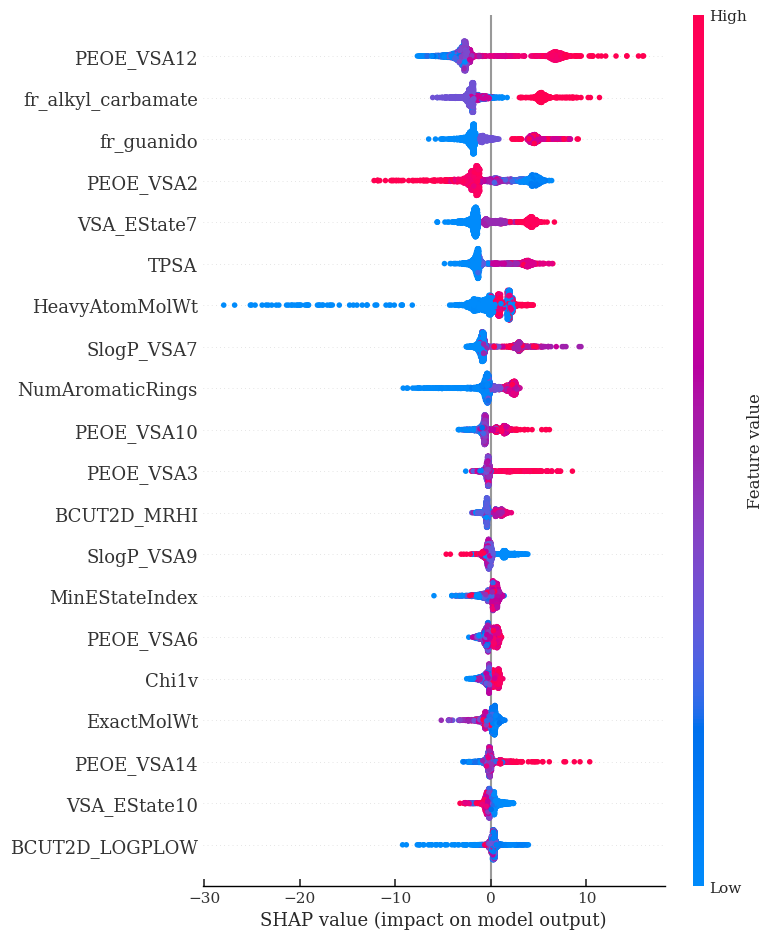

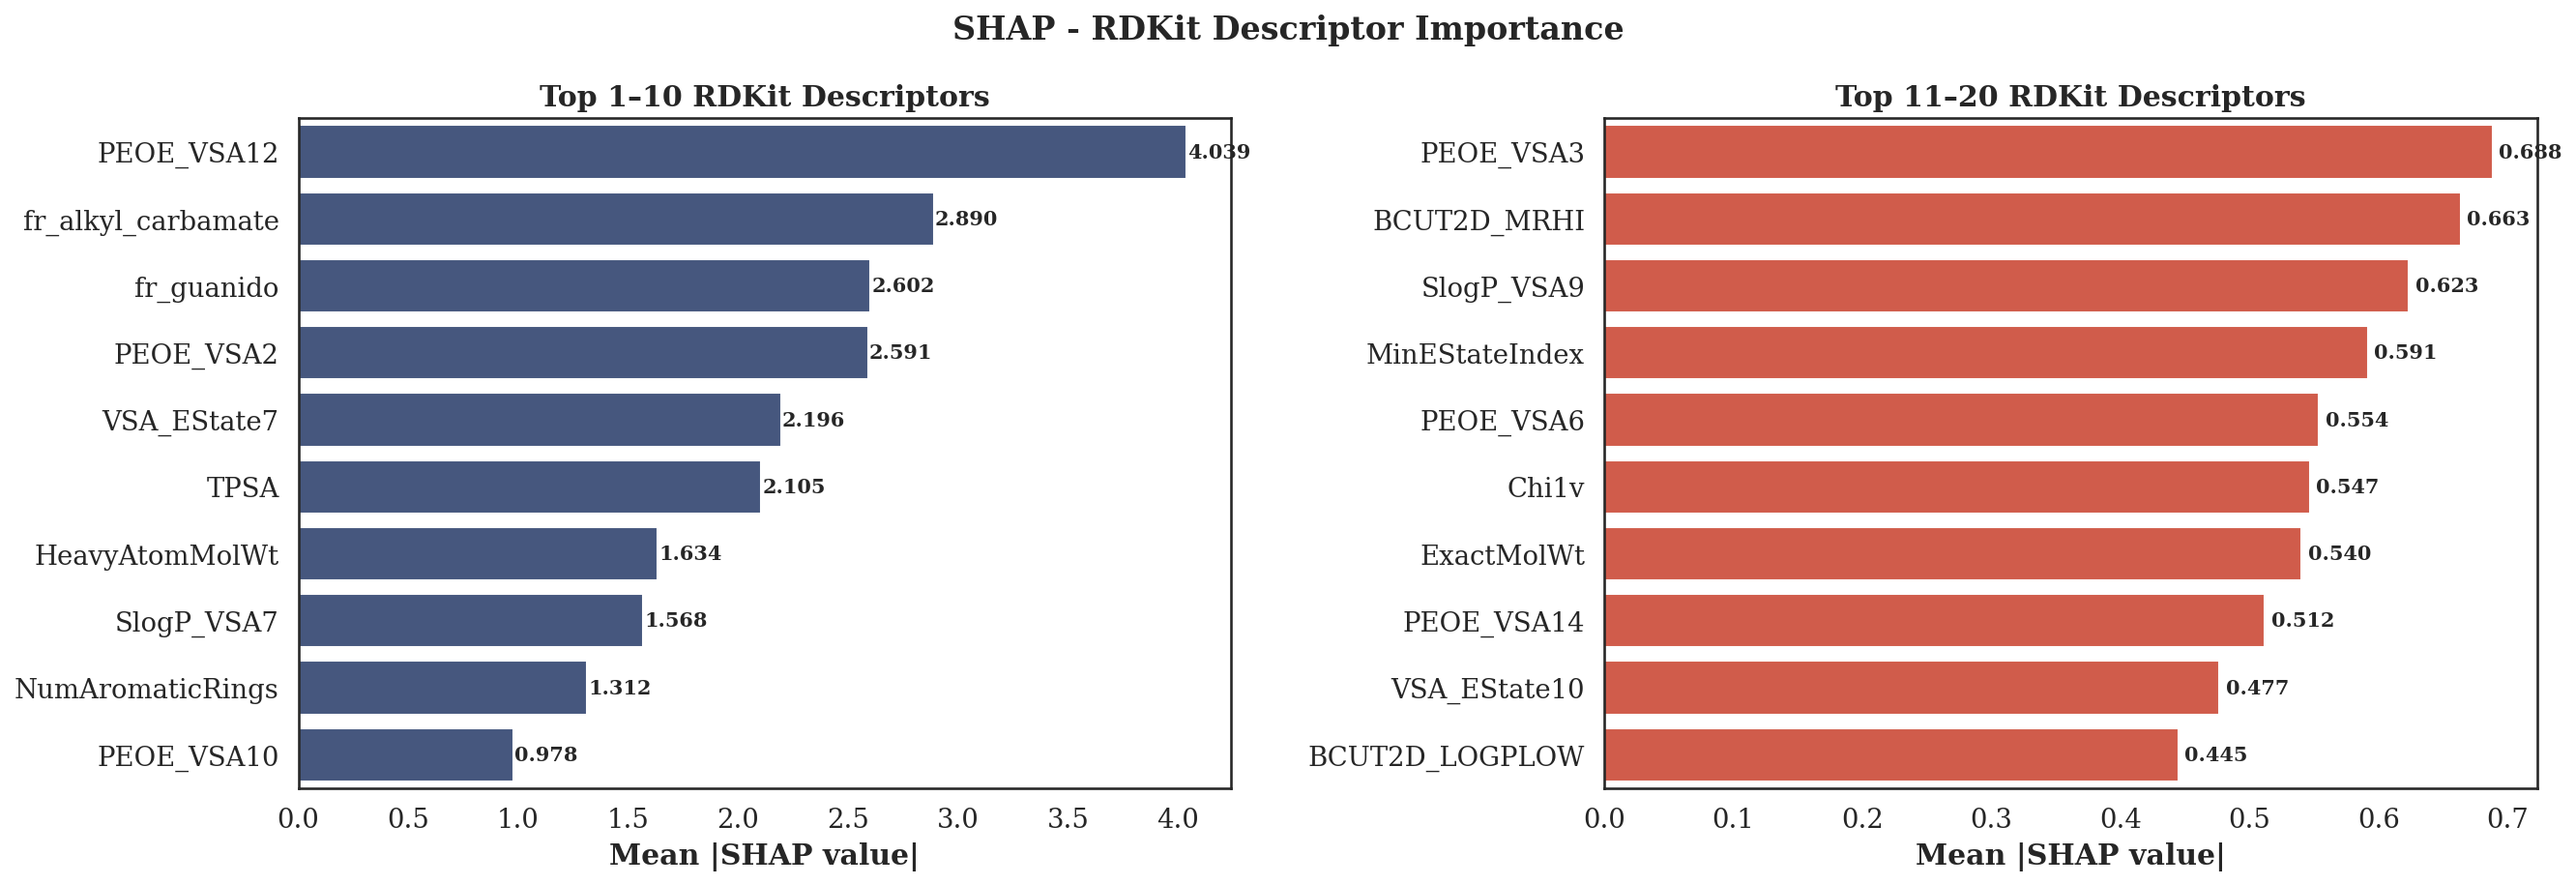

In [22]:
# All samples on the training set
best_model = best_models["RDKit"]
explainer_full = shap.TreeExplainer(best_model)
shap_values_full = explainer_full.shap_values(X_train_rdkit)
desc_names = [desc[0] for desc in Descriptors.descList]
shap.summary_plot(shap_values_full, X_train_rdkit, feature_names=desc_names)

# Shap importance of the training set 
shap_importance = np.abs(shap_values_full).mean(axis=0)
top_idx = np.argsort(shap_importance)[-20:][::-1]
top_features = [(desc_names[i], shap_importance[i]) for i in top_idx]
top_df = pd.DataFrame(top_features, columns=["Feature", "Importance"])

left_df = top_df.iloc[:10]  # Top 10
right_df = top_df.iloc[10:] # 11-20
X_train_rdkit_df = pd.DataFrame(X_train_rdkit, columns=desc_names)

sns.set_theme(style="white", font_scale=1.2)
plt.rcParams["font.family"] = "serif"

fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=150)
sns.barplot(data=left_df, x="Importance", y="Feature", ax=axes[0], color="#3C5488FF")
axes[0].set_title("Top 1–10 RDKit Descriptors",weight="bold")
axes[0].set_xlabel("Mean |SHAP value|",weight="bold")
axes[0].set_ylabel("",weight="bold")
for i, v in enumerate(left_df["Importance"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10,weight="bold")

sns.barplot(data=right_df, x="Importance", y="Feature", ax=axes[1], color="#E64B35FF")
axes[1].set_title("Top 11–20 RDKit Descriptors",weight="bold")
axes[1].set_xlabel("Mean |SHAP value|",weight="bold")
axes[1].set_ylabel("",weight="bold")
for i, v in enumerate(right_df["Importance"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10,weight="bold")

plt.suptitle("SHAP - RDKit Descriptor Importance", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.4)
plt.show()


Selected important features from RDKitDescriptors (via RF importance):
['AvgIpc', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi3v', 'EState_VSA1', 'EState_VSA10', 'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'Kappa3', 'MaxAbsEStateIndex', 'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolLogP', 'MolWt', 'PEOE_VSA10', 'PEOE_VSA14', 'PEOE_VSA3', 'PEOE_VSA4', 'SMR_VSA1', 'SMR_VSA5', 'SMR_VSA6', 'SPS', 'SlogP_VSA10', 'SlogP_VSA2', 'VSA_EState1', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'fr_alkyl_halide', 'fr_halogen']
45


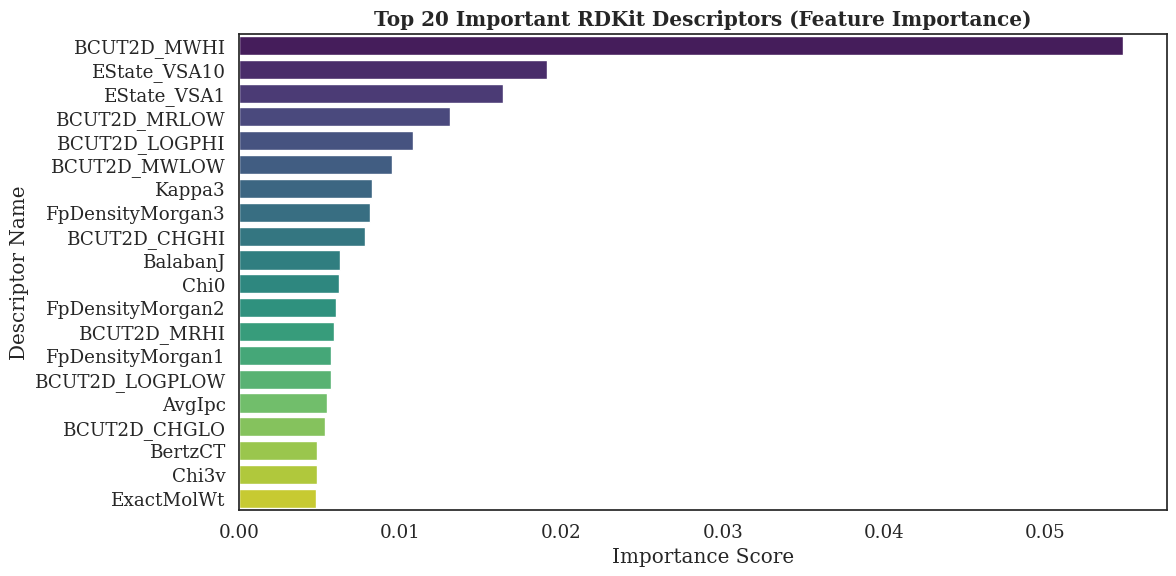

In [ ]:
# Perform feature selection based on tree model
best_model = best_models["RDKit"]
selector = SelectFromModel(
    estimator=best_model,
    threshold="mean",  
    prefit=True         
)
X_train_selected = selector.transform(X_train_rdkit)
selected_rdkit = selector.get_support(indices=True)
rdkit_feat_names = [f"{desc}" for desc in all_descriptors]
selected_feat_names = [rdkit_feat_names[i] for i in selected_rdkit]

print("\nSelected important features from RDKitDescriptors (via RF importance):")
print(selected_feat_names)
print(len(selected_feat_names))

# Visualize the final result
selected_importance = best_model.feature_importances_[selected_rdkit][:20]
selected_names = [rdkit_feat_names[i] for i in selected_rdkit[:20]]
rdkit_importance_df = pd.DataFrame({
    "Feature": selected_names,
    "Importance": selected_importance
}).sort_values("Importance", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    hue="Feature",
    data=rdkit_importance_df,
    palette="viridis",
    orient="h",
    legend=False
)
plt.title("Top 20 Important RDKit Descriptors (Feature Importance)",weight="bold")
plt.xlabel("Importance Score",weight="bold")
plt.ylabel("Descriptor Name",weight="bold")
plt.tight_layout()
plt.show()

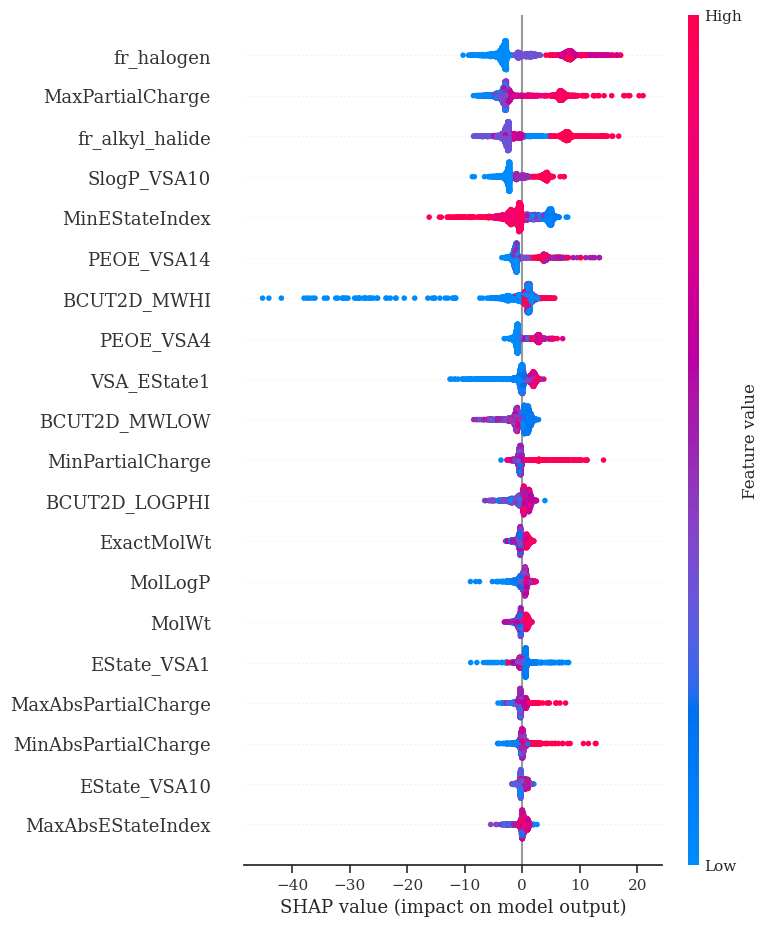

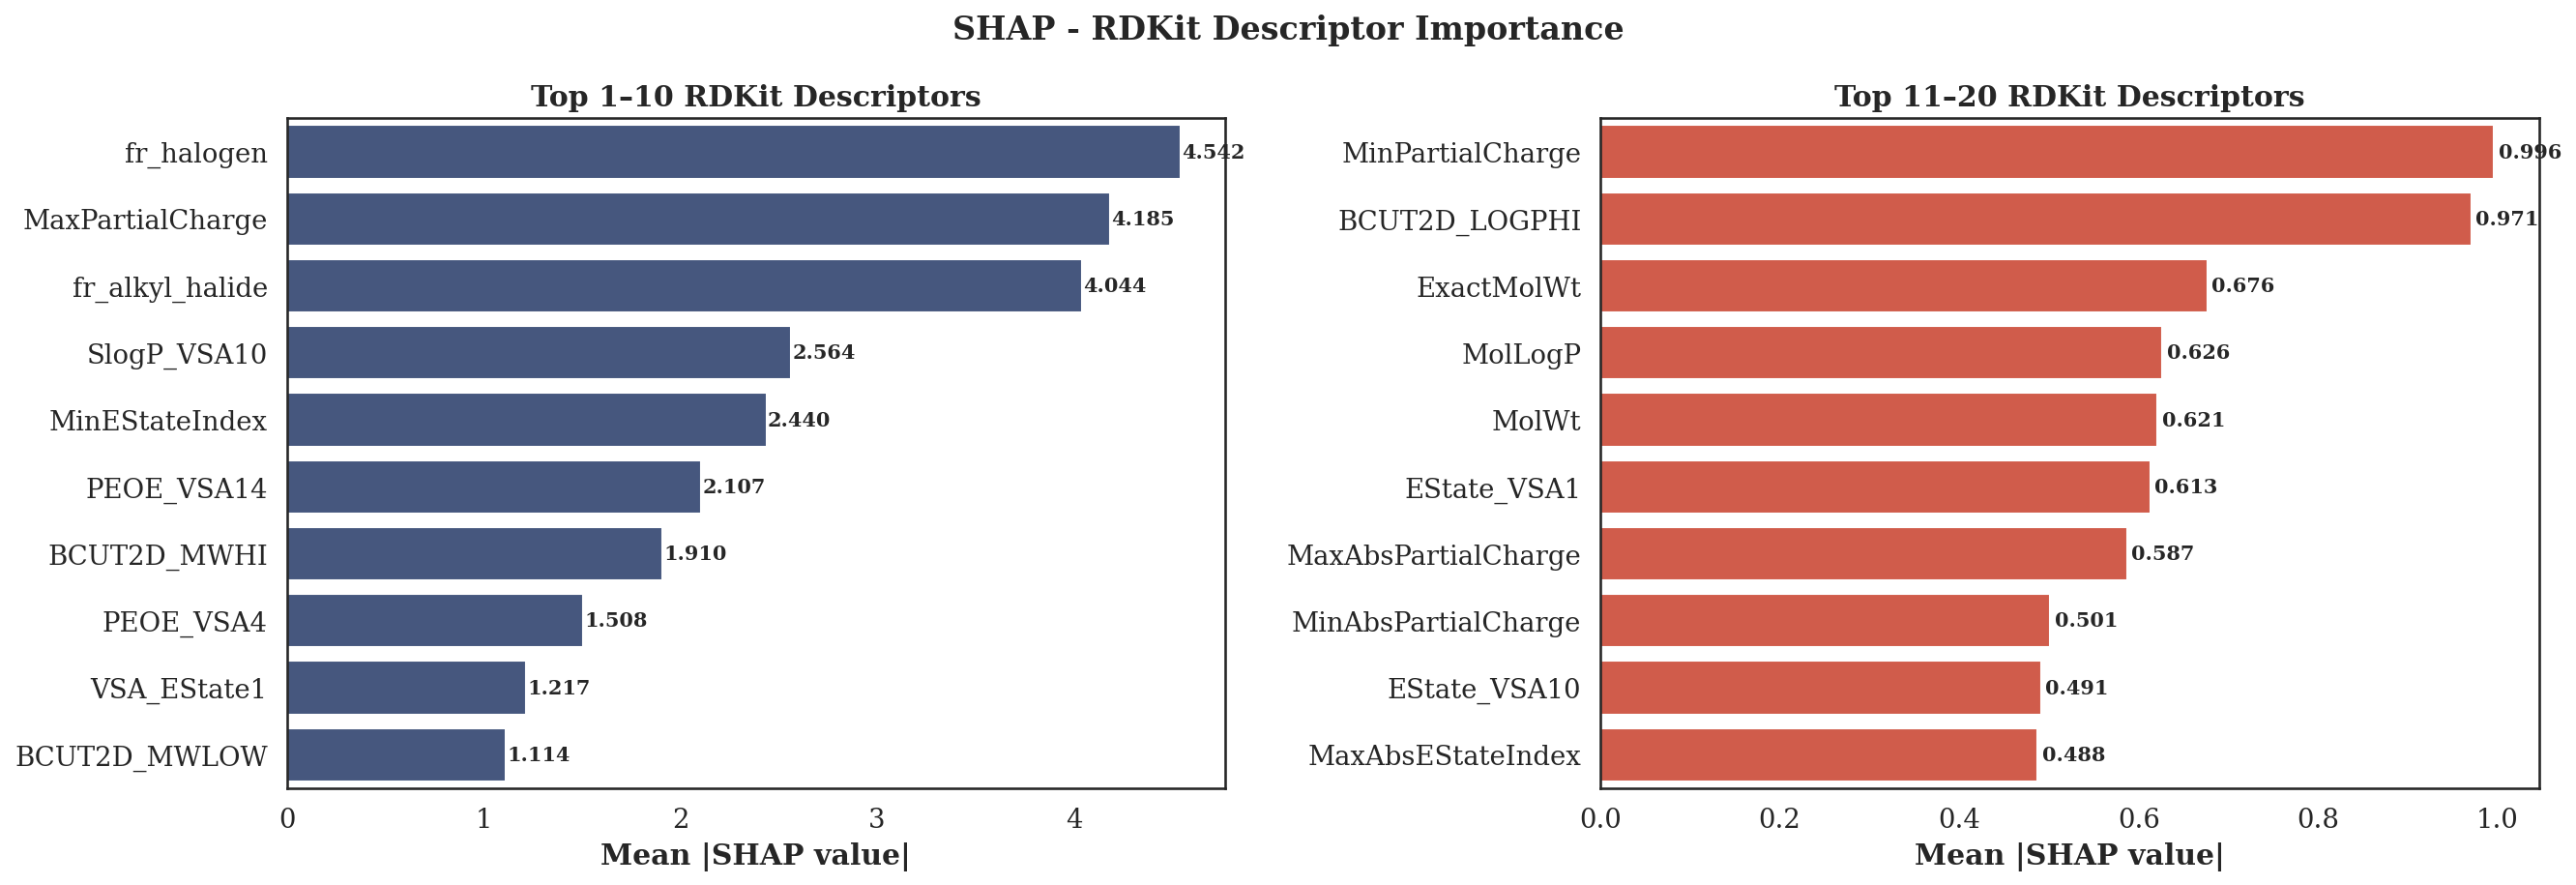

In [24]:
selected_features = selected_rdkit
X_train_selected = X_train_rdkit[:, selected_features]
model_selected = clone(best_model)
model_selected.fit(X_train_selected, y_train)
selected_feature_names = [rdkit_feat_names[i] for i in selected_features]
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
explainer = shap.TreeExplainer(model_selected)
shap_values = explainer.shap_values(X_train_selected)


# All samples on the training set
shap.summary_plot(shap_values, X_train_selected, feature_names=selected_feature_names)


# Shap importance of the training set 
shap_importance = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(shap_importance)[-20:][::-1]
top_features = [(selected_feature_names[i], shap_importance[i]) for i in top_idx]
top_df = pd.DataFrame(top_features, columns=["Feature", "Importance"])

left_df = top_df.iloc[:10]
right_df = top_df.iloc[10:]

sns.set_theme(style="white", font_scale=1.2)
plt.rcParams["font.family"] = "serif"
fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

sns.barplot(data=left_df, x="Importance", y="Feature", ax=axes[0], color="#3C5488FF")
axes[0].set_title("Top 1–10 RDKit Descriptors", weight="bold")
axes[0].set_xlabel("Mean |SHAP value|", weight="bold")
axes[0].set_ylabel("", weight="bold")
for i, v in enumerate(left_df["Importance"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10, weight="bold")

sns.barplot(data=right_df, x="Importance", y="Feature", ax=axes[1], color="#E64B35FF")
axes[1].set_title("Top 11–20 RDKit Descriptors", weight="bold")
axes[1].set_xlabel("Mean |SHAP value|", weight="bold")
axes[1].set_ylabel("", weight="bold")
for i, v in enumerate(right_df["Importance"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10, weight="bold")

plt.suptitle("SHAP - RDKit Descriptor Importance", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.4)
plt.show()

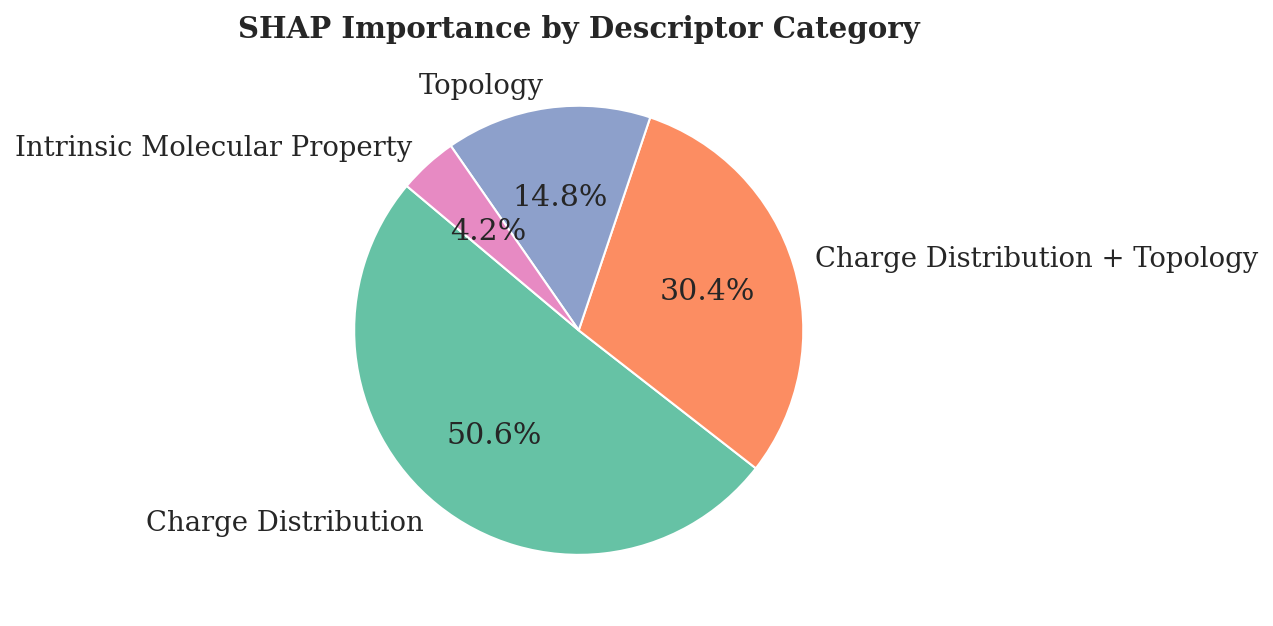

In [28]:
descriptor_categories_selection = {
    "fr_halogen": "Charge Distribution",
    "MaxPartialCharge": "Charge Distribution",
    "fr_alkyl_halide": "Charge Distribution",
    "SlogP_VSA10": "Charge Distribution + Topology",
    "MinEStateIndex": "Charge Distribution + Topology",
    "PEOE_VSA14": "Charge Distribution + Topology",
    "BCUT2D_MWHI": "Topology",
    "PEOE_VSA4": "Topology",
    "VSA_EState1": "Charge Distribution + Topology",
    "BCUT2D_MWLOW": "Topology",
    "MinPartialCharge": "Charge Distribution",
    "BCUT2D_LOGPHI": "Charge Distribution + Topology",
    "ExactMolWt": "Intrinsic Molecular Property",
    "MolLogP": "Charge Distribution",
    "MolWt": "Intrinsic Molecular Property",
    "VSA_EState10": "Charge Distribution + Topology",
    "MaxAbsPartialCharge": "Charge Distribution",
    "MinAbsPartialCharge": "Charge Distribution",
    "MaxEStateIndex": "Charge Distribution + Topology"
}



top_df["Category"] = top_df["Feature"].map(descriptor_categories_selection)
category_importance = top_df.groupby("Category")["Importance"].sum().sort_values(ascending=False)
colors = sns.color_palette("Set2", n_colors=len(category_importance))

plt.figure(figsize=(8, 8), dpi=150)
plt.pie(category_importance, labels=category_importance.index,
        autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("SHAP Importance by Descriptor Category", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()